# Time Series Analysis — Delta at NTM Strikes

Análisis de estacionariedad y primeras diferencias del delta interpolado en cuantiles de moneyness, para calls y puts.

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.widgets import Button
import math
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

PARQUET_PATH = r"C:\Users\pablo.esparcia\Documents\OptionMetrics\output\time_series\quantile_delta.parquet"

## 1. Carga de datos

In [112]:
quantile_deltas = pd.read_parquet(PARQUET_PATH).set_index("Date")
quantile_deltas.index = pd.to_datetime(quantile_deltas.index)

print(f"Periodo: {quantile_deltas.index.min().date()} → {quantile_deltas.index.max().date()}")
print(f"Observaciones: {len(quantile_deltas):,} | Series: {quantile_deltas.shape[1]}")
quantile_deltas.describe().round(4)

Periodo: 2003-01-02 → 2024-02-28
Observaciones: 3,968 | Series: 20


,10C,20C,30C,40C,50C,60C,70C,80C,90C,100C,10P,20P,30P,40P,50P,60P,70P,80P,90P,100P
count,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000,3968.0000
mean,0.4839,0.4077,0.2639,0.2056,0.1248,0.0995,0.0585,0.0459,0.0319,0.0271,-0.0053,-0.0064,-0.0088,-0.0119,-0.0197,-0.0325,-0.0580,-0.1114,-0.2242,-0.3759
std,0.0397,0.0641,0.1023,0.1090,0.1034,0.0961,0.0749,0.0652,0.0520,0.0472,0.0136,0.0142,0.0157,0.0178,0.0228,0.0296,0.0394,0.0496,0.0471,0.0219
min,0.3650,0.1886,0.0090,0.0003,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.2413,-0.2413,-0.2413,-0.2413,-0.2413,-0.2413,-0.2460,-0.2935,-0.3473,-0.4293
25%,0.4561,0.3624,0.1876,0.1188,0.0418,0.0240,0.0054,0.0025,0.0008,0.0003,-0.0038,-0.0052,-0.0087,-0.0133,-0.0244,-0.0416,-0.0762,-0.1424,-0.2588,-0.3918
50%,0.4823,0.4070,0.2579,0.1922,0.0962,0.0686,0.0296,0.0203,0.0104,0.0070,-0.0014,-0.0021,-0.0037,-0.0058,-0.0118,-0.0225,-0.0458,-0.1002,-0.2198,-0.3755
75%,0.5106,0.4536,0.3386,0.2832,0.1870,0.1510,0.0844,0.0631,0.0407,0.0334,-0.0005,-0.0009,-0.0017,-0.0028,-0.0060,-0.0125,-0.0289,-0.0730,-0.1890,-0.3620
max,0.6796,0.6623,0.6235,0.6073,0.5780,0.5659,0.5275,0.4999,0.4723,0.4723,0.0003,0.0003,0.0003,0.0003,-0.0001,-0.0022,-0.0056,-0.0214,-0.0995,-0.2910


## 2. Series en niveles

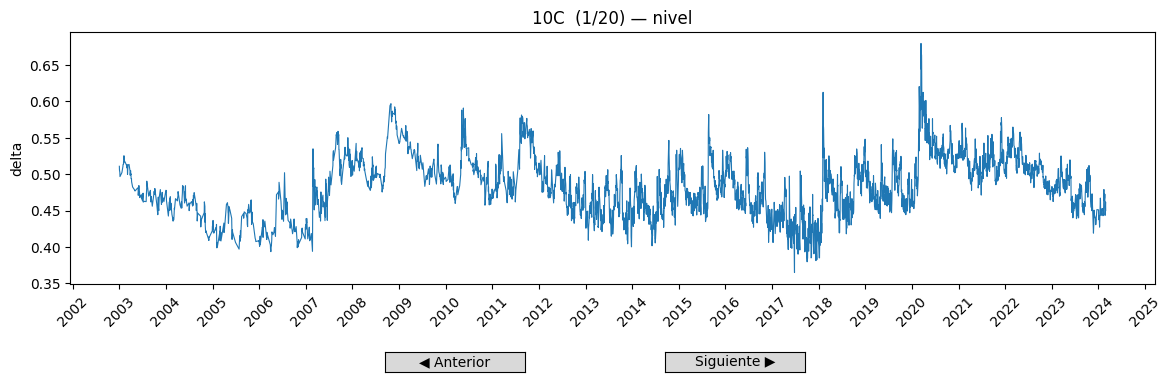

In [113]:
cols = list(quantile_deltas.columns)
idx  = [0]

fig, ax = plt.subplots(figsize=(14, 4))
plt.subplots_adjust(bottom=0.25)

def update_levels():
    col = cols[idx[0]]
    ax.cla()
    ax.plot(quantile_deltas.index, quantile_deltas[col], linewidth=0.8)
    ax.set_title(f"{col}  ({idx[0]+1}/{len(cols)}) — nivel")
    ax.set_ylabel("delta")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    fig.canvas.draw()

ax_prev = plt.axes([0.35, 0.03, 0.1, 0.05])
ax_next = plt.axes([0.55, 0.03, 0.1, 0.05])
Button(ax_prev, '◀ Anterior').on_clicked(lambda _: [idx.__setitem__(0, (idx[0]-1) % len(cols)), update_levels()])
Button(ax_next, 'Siguiente ▶').on_clicked(lambda _: [idx.__setitem__(0, (idx[0]+1) % len(cols)), update_levels()])

update_levels()
plt.show()

## 3. Test ADF — Niveles I(0)

Contraste de raíz unitaria con constante, tendencia lineal y término cuadrático (`regression='ctt'`).

- **H₀**: la serie tiene raíz unitaria (no estacionaria)
- Rechazamos H₀ si p-value < 5 %

In [114]:
rows = []
for col in quantile_deltas.columns:
    res = adfuller(quantile_deltas[col].dropna(), regression="ctt")
    rows.append({"serie": col, "p-value (%)": round(res[1]*100, 4), "estacionaria": res[1] < 0.05})


adf_diff = pd.DataFrame(rows).set_index("serie")
adf_diff.style.map(lambda v: "background-color: #d4edda; color: #155724" if v else "background-color: #f8d7da; color: #721c24",
                         subset=["estacionaria"])

,p-value (%),estacionaria
serie,,
10C,0.468300,True
20C,1.585500,True
30C,2.324000,True
40C,0.086300,True
50C,0.147000,True
60C,0.066700,True
70C,0.003400,True
80C,0.000700,True
90C,0.008900,True


## 4. Primeras diferencias porcentuales

Calculamos `pct_change()` para obtener las series I(1) y comprobamos si son estacionarias.

In [115]:
quantile_diff = quantile_deltas.pct_change().iloc[1:-1]
quantile_diff.describe().round(4)

,10C,20C,30C,40C,50C,60C,70C,80C,90C,100C,10P,20P,30P,40P,50P,60P,70P,80P,90P,100P
count,3966.0000,3966.0000,3966.0000,3966.0000,3.966000e+03,3.966000e+03,3.966000e+03,3.966000e+03,3.966000e+03,3.966000e+03,3966.0000,3966.0000,3966.0000,3966.0000,3966.0000,3966.0000,3966.0000,3966.0000,3966.0000,3966.0000
mean,0.0003,0.0012,0.0225,0.1553,5.313818e+03,5.523053e+05,4.137935e+11,1.585575e+20,7.356579e+43,1.477134e+44,1.8186,1.0588,0.5769,0.3532,0.1756,0.0547,0.0200,0.0072,0.0017,0.0003
std,0.0276,0.0513,0.2748,2.1139,3.134134e+05,3.433250e+07,2.312845e+13,7.126396e+21,4.630397e+45,6.575274e+45,35.3416,16.4805,7.6107,4.0445,3.0054,0.4862,0.2338,0.1344,0.0599,0.0251
min,-0.1185,-0.2419,-0.8253,-0.9914,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-979.7834,-337.0858,-118.5705,-72.2058,-0.9776,-0.9016,-0.7879,-0.5220,-0.2289,-0.2236
25%,-0.0157,-0.0253,-0.0571,-0.0806,-1.589000e-01,-2.241000e-01,-4.540000e-01,-5.642000e-01,-7.470000e-01,-8.265000e-01,-0.3218,-0.2656,-0.2195,-0.1899,-0.1530,-0.1233,-0.0918,-0.0631,-0.0313,-0.0138
50%,-0.0010,-0.0023,-0.0058,-0.0085,-1.150000e-02,-1.520000e-02,-1.450000e-02,-7.100000e-03,3.270000e-02,8.780000e-02,-0.0223,-0.0183,-0.0201,-0.0164,-0.0156,-0.0160,-0.0103,-0.0069,-0.0020,0.0003
75%,0.0139,0.0223,0.0517,0.0797,1.869000e-01,2.801000e-01,8.824000e-01,1.485000e+00,3.393700e+00,5.404300e+00,0.4738,0.3549,0.2659,0.2138,0.1612,0.1257,0.0899,0.0580,0.0293,0.0134
max,0.3574,0.5693,5.0855,68.8623,1.969538e+07,2.162040e+09,1.449012e+15,3.584308e+23,2.916048e+47,2.940696e+47,1449.4862,667.4538,318.6530,179.7372,179.7372,10.1406,4.1403,3.6677,0.4398,0.2473


## 5. Test ADF — Primeras diferencias I(1)

In [116]:
rows = []
for col in quantile_diff.columns:
    res = adfuller(quantile_diff[col].dropna(), regression="ctt")
    rows.append({"serie": col, "p-value (%)": round(res[1]*100, 4), "estacionaria": res[1] < 0.05})

adf_diff = pd.DataFrame(rows).set_index("serie")
adf_diff.style.map(lambda v: "background-color: #d4edda; color: #155724" if v else "background-color: #f8d7da; color: #721c24",
                         subset=["estacionaria"])

,p-value (%),estacionaria
serie,,
10C,0.000000,True
20C,0.000000,True
30C,0.000000,True
40C,0.000300,True
50C,0.000000,True
60C,0.000000,True
70C,0.000000,True
80C,0.000000,True
90C,0.000000,True


## 6. Series en primeras diferencias

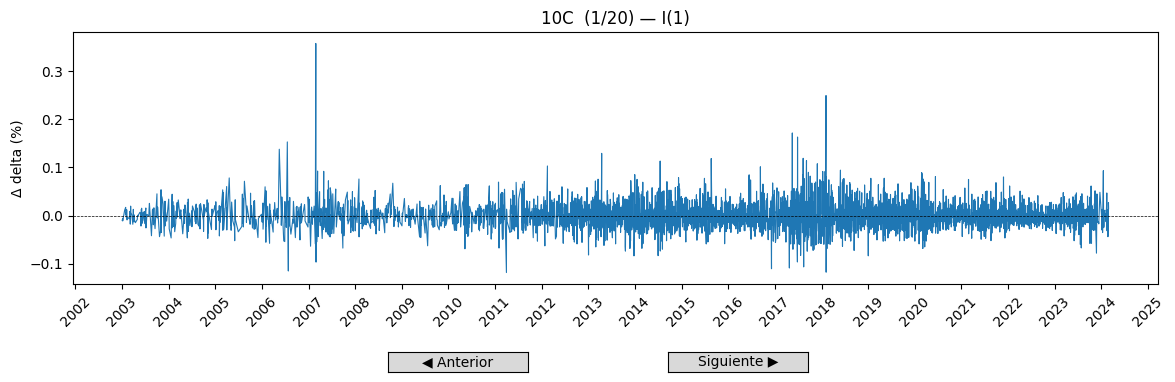

In [117]:
cols_d = list(quantile_diff.columns)
idx_d  = [0]

fig, ax = plt.subplots(figsize=(14, 4))
plt.subplots_adjust(bottom=0.25)

def update_diff():
    col = cols_d[idx_d[0]]
    ax.cla()
    ax.plot(quantile_diff.index, quantile_diff[col], linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f"{col}  ({idx_d[0]+1}/{len(cols_d)}) — I(1)")
    ax.set_ylabel("Δ delta (%)")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45)
    fig.canvas.draw()

ax_prev = plt.axes([0.35, 0.03, 0.1, 0.05])
ax_next = plt.axes([0.55, 0.03, 0.1, 0.05])
Button(ax_prev, '◀ Anterior').on_clicked(lambda _: [idx_d.__setitem__(0, (idx_d[0]-1) % len(cols_d)), update_diff()])
Button(ax_next, 'Siguiente ▶').on_clicked(lambda _: [idx_d.__setitem__(0, (idx_d[0]+1) % len(cols_d)), update_diff()])

update_diff()
plt.show()

## 7. Análisis de autocorrelaciones. 
#### 7.1. Gráficas de ACF I(1):

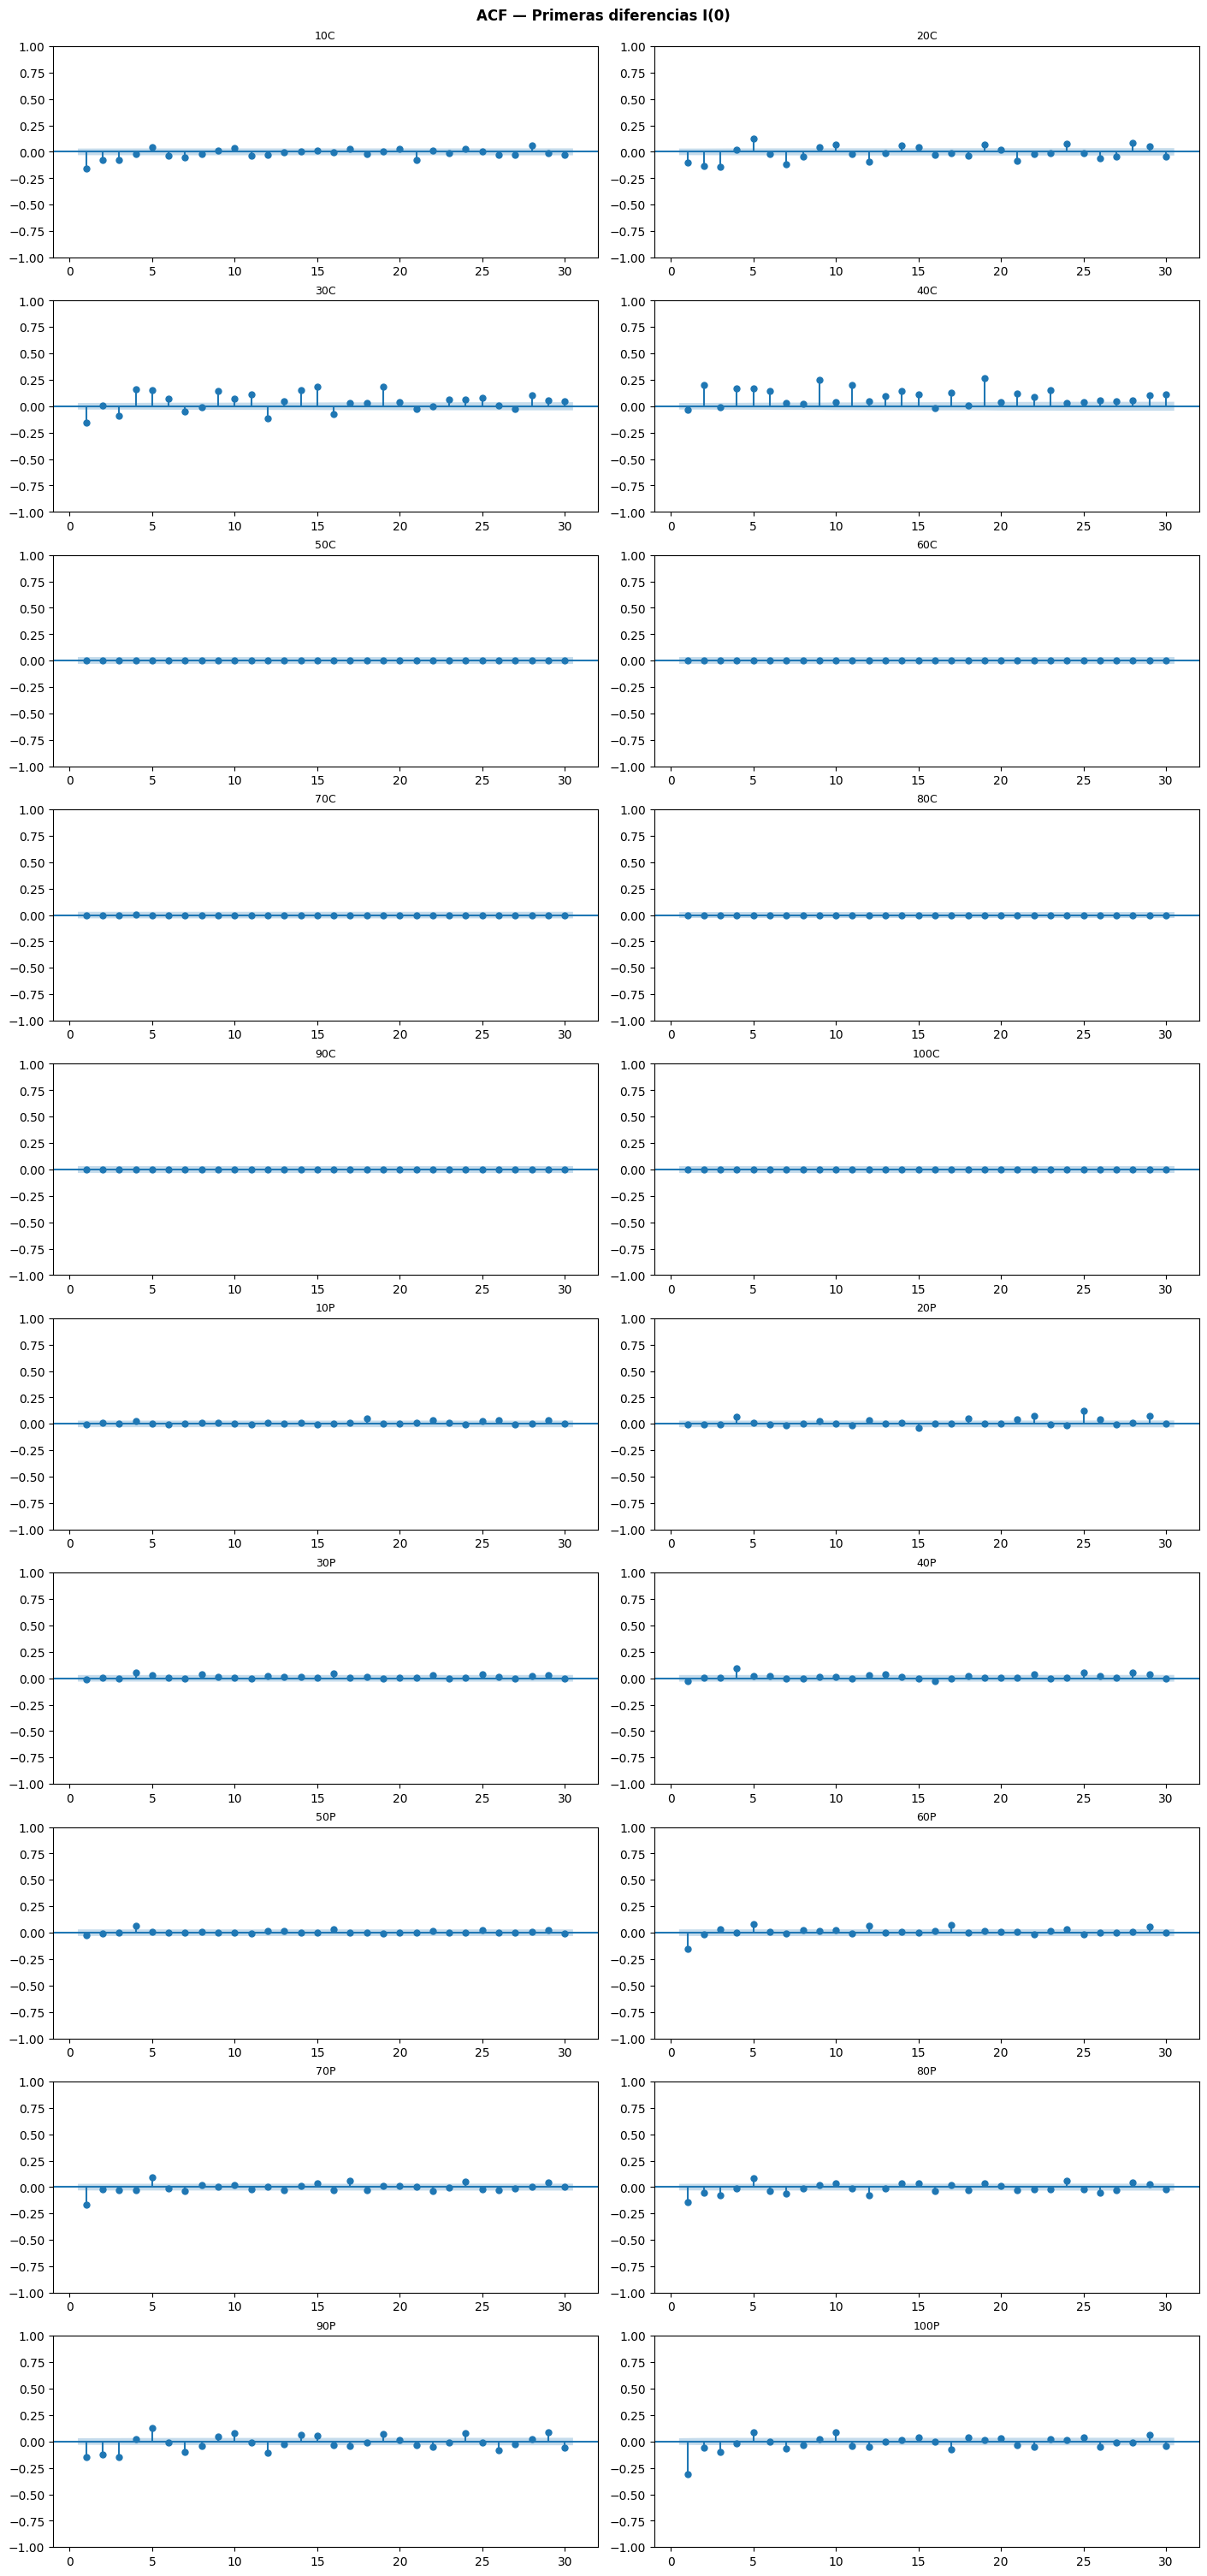

In [118]:
n = len(cols_d)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(cols_d):
    plot_acf(quantile_diff[col].dropna(), lags=30, ax=axes[i], zero=False, alpha=0.05)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("ACF — Primeras diferencias I(0)", fontsize=12, fontweight="bold")
plt.show()


#### 7.2. Gráficas de PACF I(1):

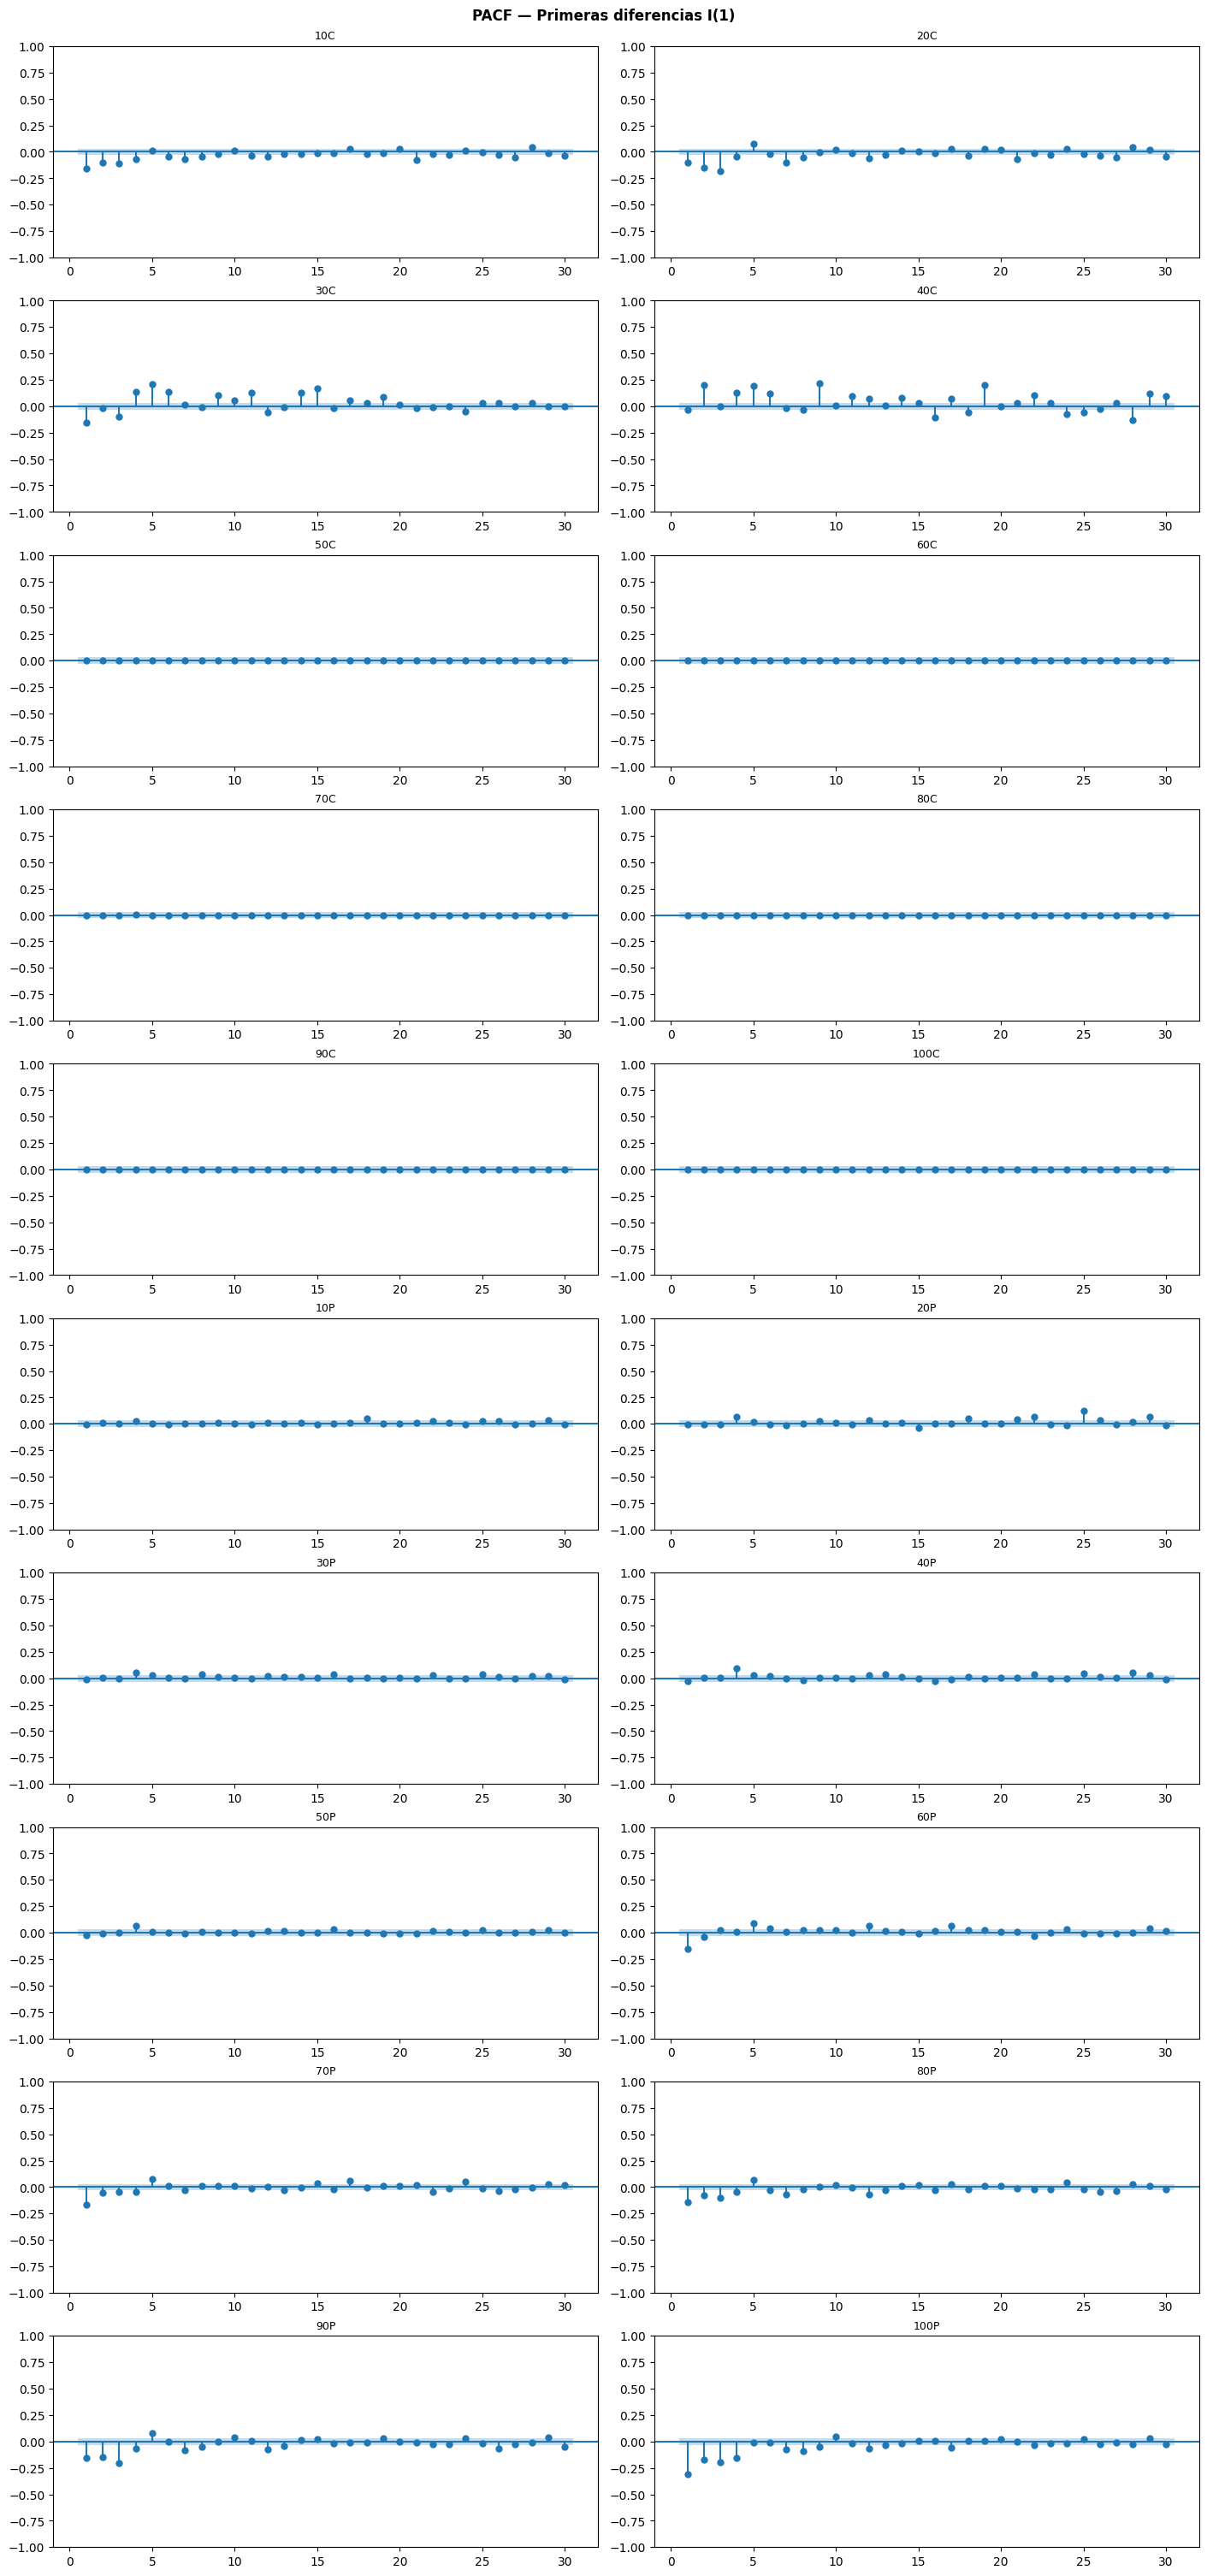

In [119]:
n = len(cols_d)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(cols_d):
    plot_pacf(quantile_diff[col], lags=30, ax=axes[i], zero=False, method="ols", alpha=0.05)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("PACF — Primeras diferencias I(1)", fontsize=12, fontweight="bold")
plt.show()


#### 7.3. Gráficas de ACF I(1) con diferencias al cuadrado:

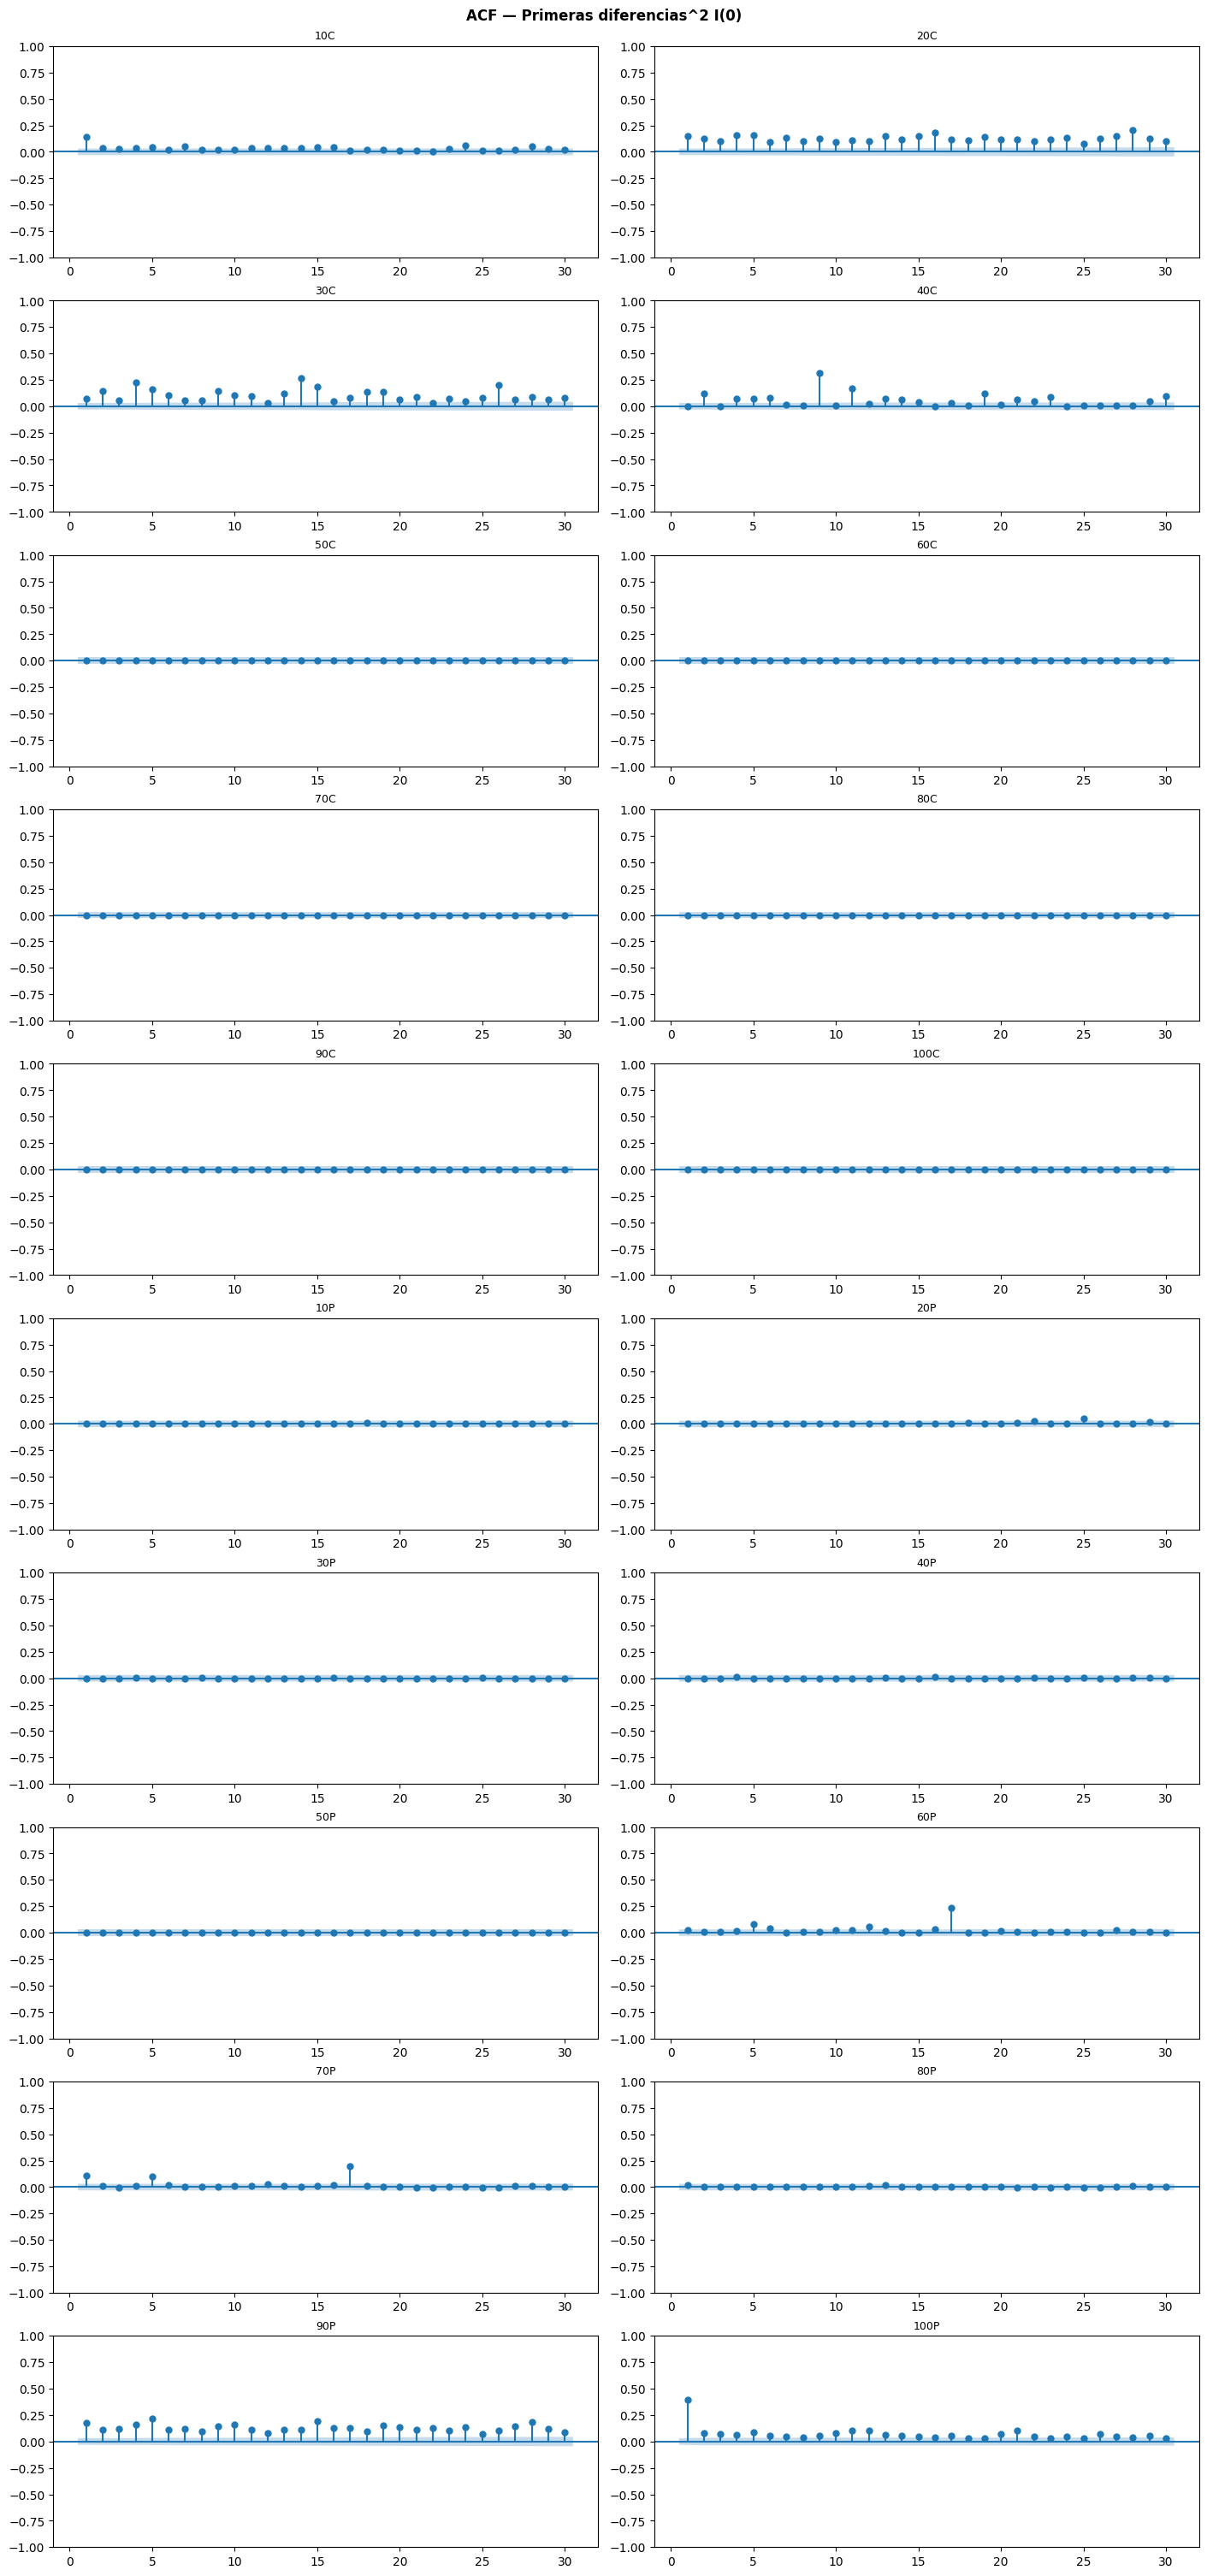

In [120]:
n = len(cols_d)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), constrained_layout=True)
axes = axes.flatten()

quantile_diff_sqrt = quantile_diff**2

for i, col in enumerate(cols_d):
    plot_acf(quantile_diff_sqrt[col].dropna(), lags=30, ax=axes[i], zero=False, alpha=0.05)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("ACF — Primeras diferencias^2 I(0)", fontsize=12, fontweight="bold")
plt.show()


#### 7.4. Gráficas de PACF I(1) con diferencias al cuadrado:

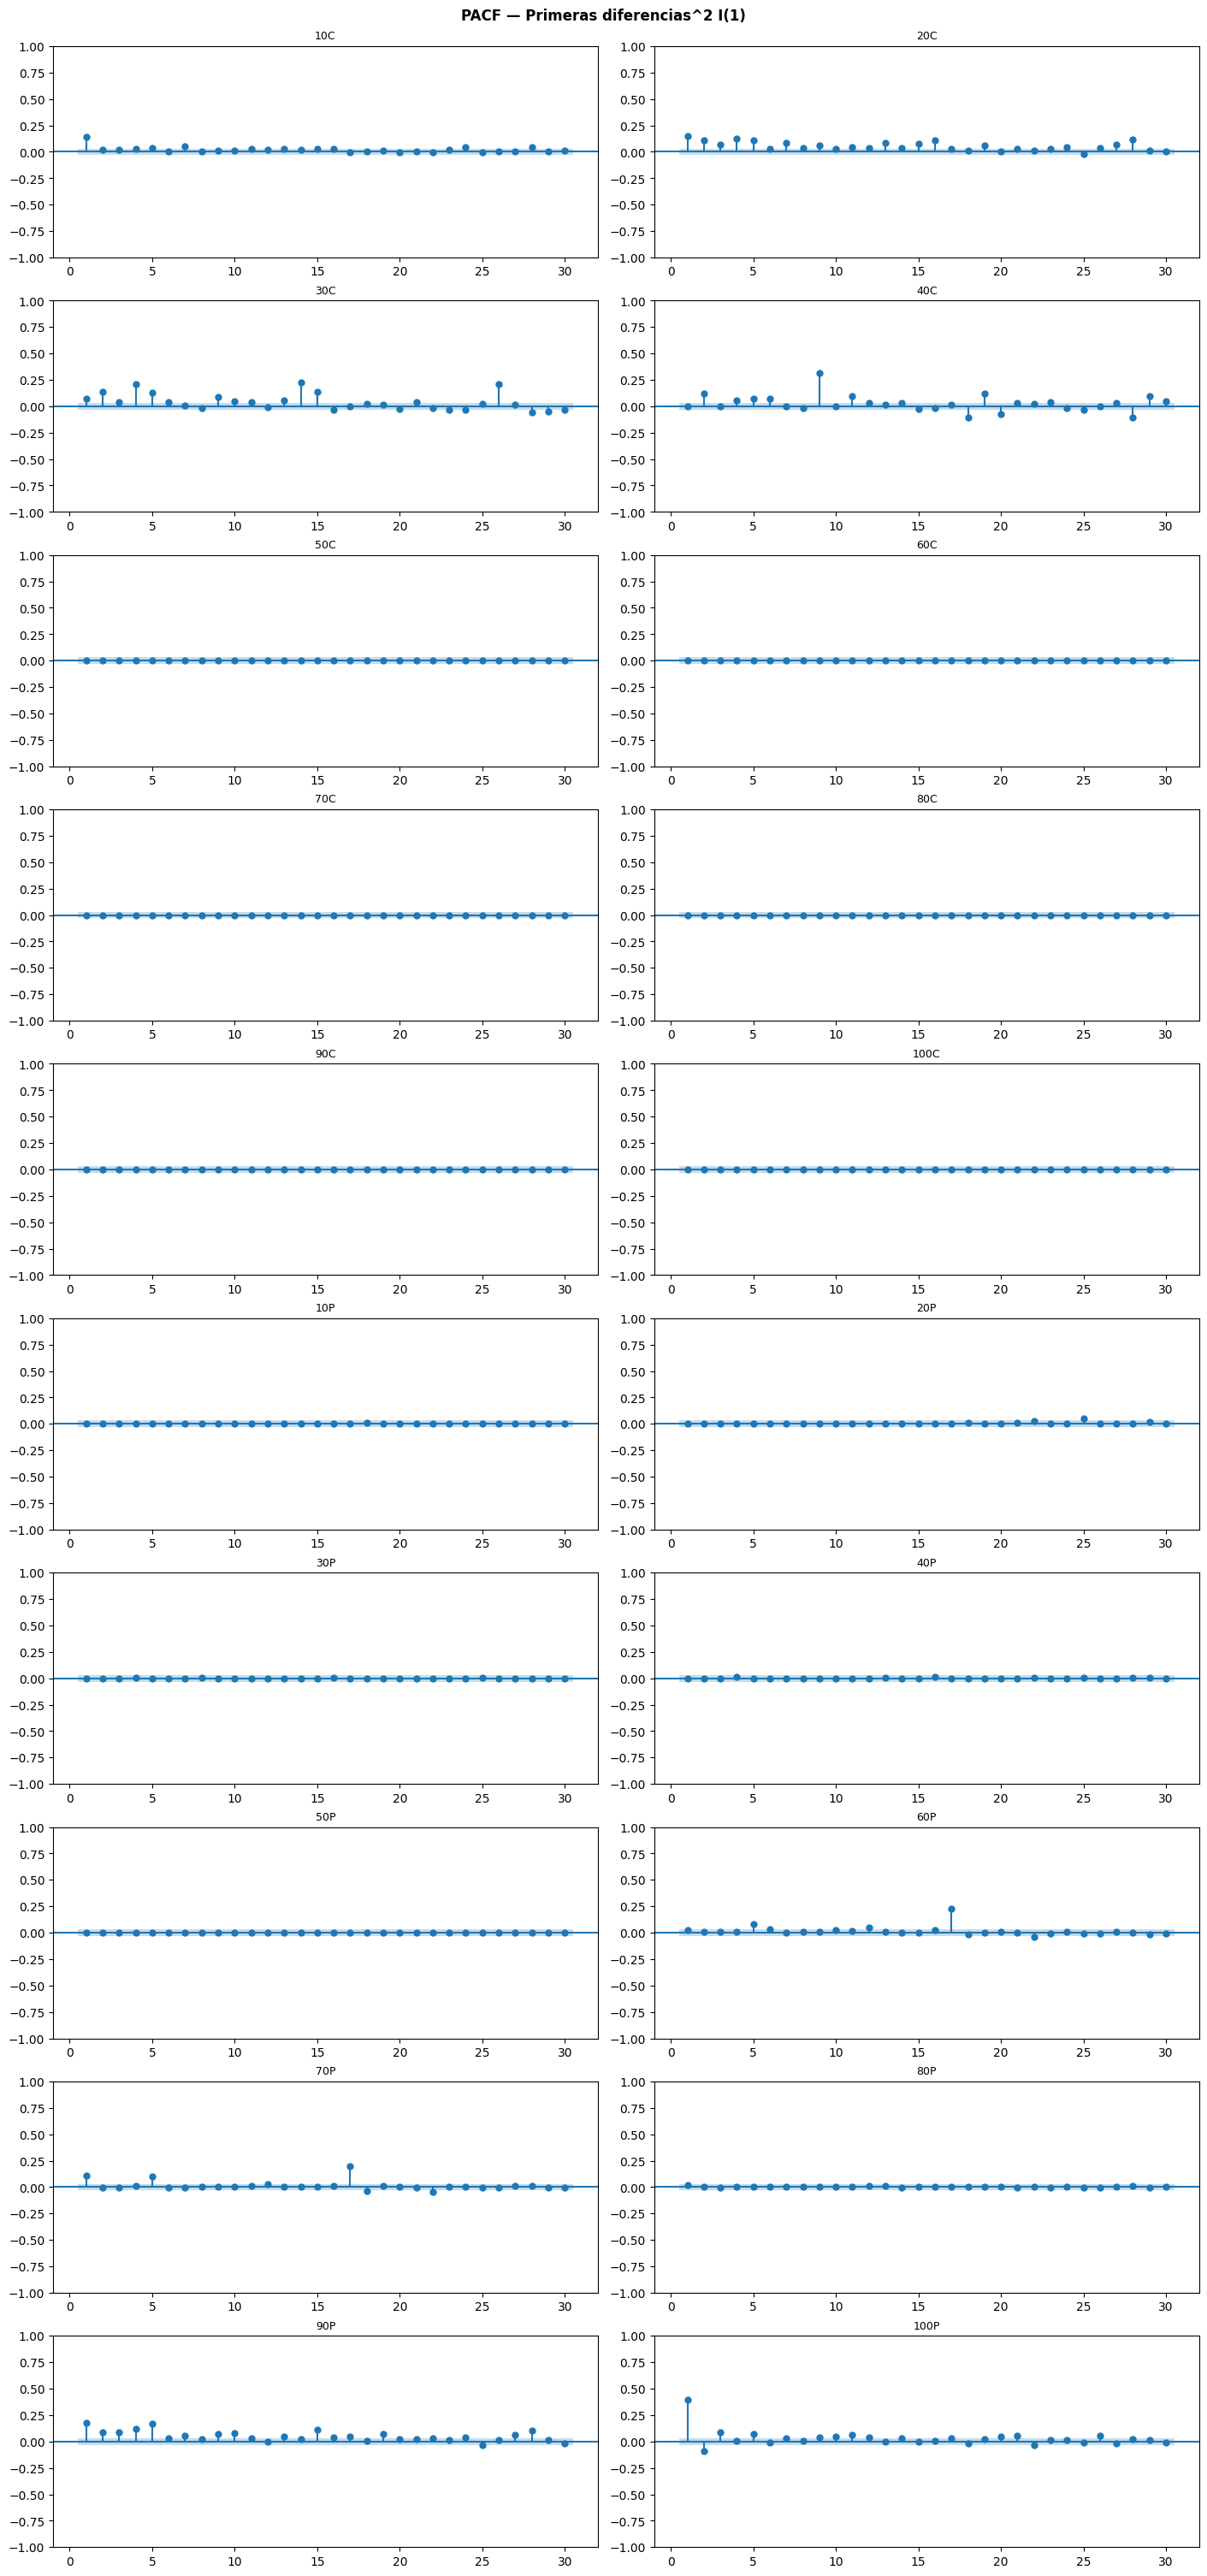

In [121]:
n = len(cols_d)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(cols_d):
    plot_pacf(quantile_diff_sqrt[col], lags=30, ax=axes[i], zero=False, method="ols", alpha=0.05)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("PACF — Primeras diferencias^2 I(1)", fontsize=12, fontweight="bold")
plt.show()
